In [1]:
import os  # 设置代理环境变量，指向你打通的 1082 端口

os.environ["http_proxy"] = "http://127.0.0.1:1082"
os.environ["https_proxy"] = "http://127.0.0.1:1082"


## 评估简单RAG中的块大小

在Retrieval-Augmented Generation (RAG) 管道中，选择合适的块大小对于提高检索准确性至关重要。目标是平衡检索性能与回复质量。

本节通过以下步骤评估不同的块大小：

1. 从PDF中提取文本。
2. 将文本拆分为不同大小的块。
3. 为每个块创建嵌入向量。
4. 根据查询检索相关的块。
5. 使用检索到的块生成回复。
6. 评估忠实性和相关性。
7. 比较不同块大小的结果。

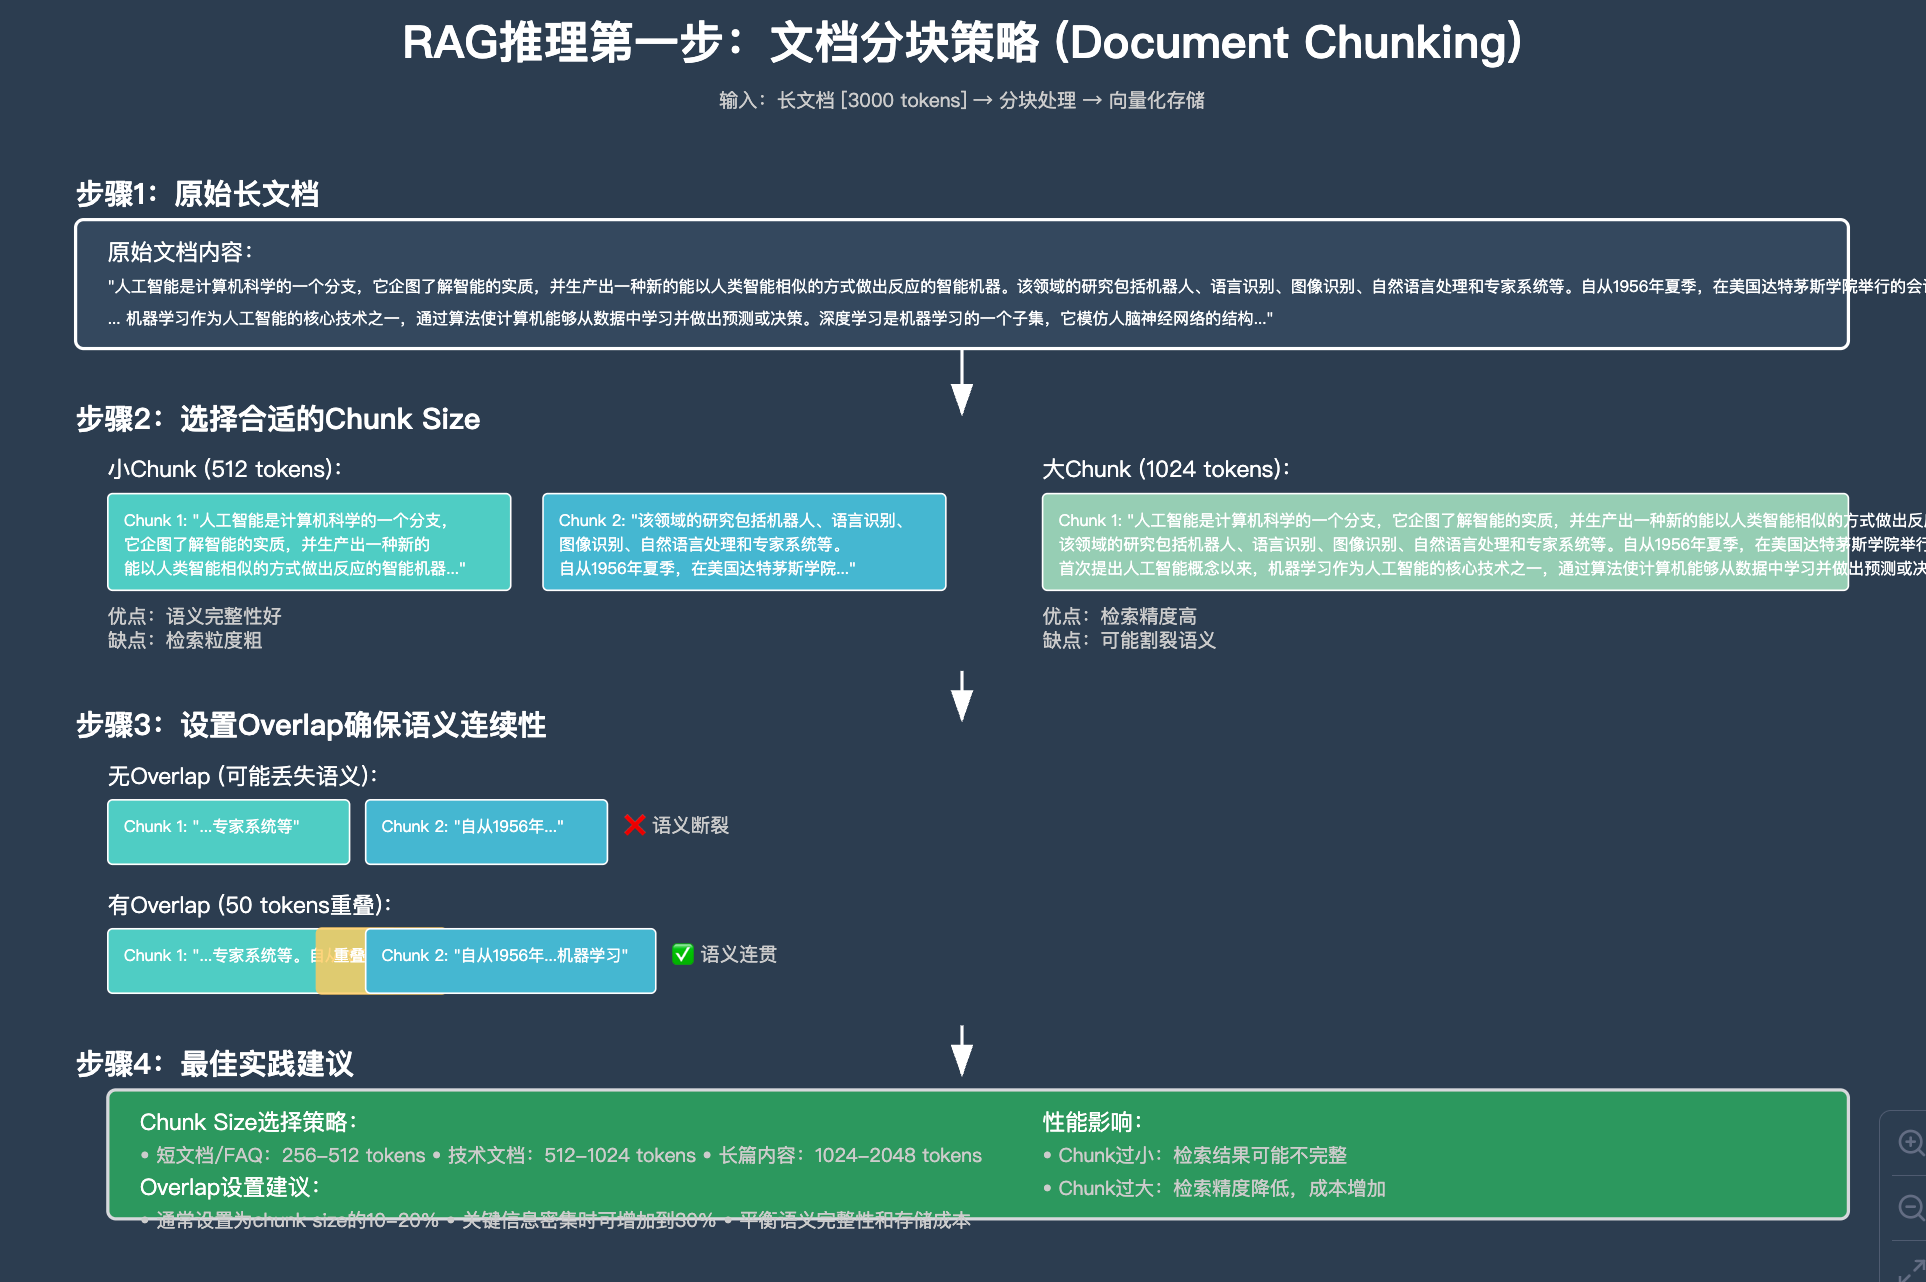

## 环境设置  
我们首先导入必要的库。

In [2]:
import fitz  # PyMuPDF，用于处理 PDF 文件
import numpy as np
import json
from openai import OpenAI  # OpenAI API 客户端


from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("DASHSCOPE_API_KEY")
client = OpenAI(
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1", api_key=api_key
)


## 从PDF中提取文本  
首先，我们将从`AI_Information.pdf`文件中提取文本。

In [3]:
def extract_text_from_pdf(pdf_path):
    """
    从PDF文件中提取文本。

    参数:
    pdf_path (str): PDF文件的路径。

    返回:
    str: 从PDF中提取的文本。
    """
    # 打开PDF文件
    mypdf = fitz.open(pdf_path)
    all_text = ""  # 初始化一个空字符串用于存储提取的文本

    # 遍历PDF中的每一页
    for page in mypdf:
        # 从当前页提取文本并添加间距
        all_text += page.get_text("text") + " "

    # 返回提取的文本，并去除首尾的空白字符
    return all_text.strip()


# 定义PDF文件的路径
pdf_path = "data/2024年AI行业报告.pdf"

# 从PDF文件中提取文本
extracted_text = extract_text_from_pdf(pdf_path)

# 打印提取文本的前500个字符
print(extracted_text[:500])


前
言
伴随人工智能技术的加速演进，AI 大模型已成为全球科技竞争的新高地、
未来产业的新赛道、经济发展的新引擎，发展潜力大、应用前景广。近年来，我
国高度重视人工智能的发展，将其上升为国家战略，出台一系列扶持政策和规划，
为AI 大模型产业发展创造了良好的环境。当前，通用大模型、行业大模型、端
侧大模型如雨后春笋般涌现，大模型产业的应用落地将进一步提速。作为新一代
人工智能产业的核心驱动力，AI 大模型广泛赋能我国经济社会的多个领域，打
开迈向通用人工智能的大门，推动新一轮的科技革命与产业变革。在大模型盛行
的时代，产业发展到何种阶段，遇到何种挑战，未来将走向何方，这些都是需要
面对的问题，亟需社会各界共同努力。
在此背景下，人民网财经研究院、至顶科技联合发布《开启智能新时代：2024
年中国AI 大模型产业发展报告》，报告对于AI 大模型产业发展背景、产业发展
现状、典型案例、挑战及未来趋势等方面进行了系统全面的梳理，为政府部门、
行业从业者以及社会公众更好了解AI 大模型产业提供参考。
 专家寄语
2023 年人工智能大模型全面爆发，给科技创新、生产生活带来重大变革、
机遇和挑战


## 提取文本的分块
为了提高检索效率，我们将提取的文本分割为不同大小的重叠块。

In [4]:
def chunk_text(text, n, overlap):
    """
    将文本分割为重叠的块。

    参数:
    text (str): 需要分块的文本。
    n (int): 每个块的字符数。
    overlap (int): 块之间的重叠字符数。

    返回:
    List[str]: 一个包含文本块的列表。
    """
    chunks = []  # 初始化一个空列表来存储块
    for i in range(0, len(text), n - overlap):
        # 从当前索引到索引 + 块大小范围内追加一个块
        chunks.append(text[i : i + n])

    return chunks  # 返回文本块的列表


# 定义不同的块大小以进行评估
chunk_sizes = [128, 256, 512]

# 创建一个字典来存储每个块大小的文本块
text_chunks_dict = {
    size: chunk_text(extracted_text, size, size // 5) for size in chunk_sizes
}

# 打印每个块大小创建的块的数量
for size, chunks in text_chunks_dict.items():
    print(f"Chunk Size: {size}, Number of Chunks: {len(chunks)}")


Chunk Size: 128, Number of Chunks: 263
Chunk Size: 256, Number of Chunks: 132
Chunk Size: 512, Number of Chunks: 66


## 创建文本块的嵌入
嵌入将文本转换为用于相似性搜索的数值表示。

In [5]:
import numpy as np
from tqdm import tqdm


def create_embeddings(texts, model="text-embedding-v4", batch_size=10):
    """
    为一组文本生成嵌入向量，增加分批处理逻辑。
    """
    all_embeddings = []

    # 将 texts 切分为大小为 batch_size 的组
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        try:
            # 这里的 client 假设你已经初始化过了
            response = client.embeddings.create(model=model, input=batch)
            # 提取当前批次的向量
            batch_embeddings = [np.array(e.embedding) for e in response.data]
            all_embeddings.extend(batch_embeddings)
        except Exception as e:
            print(f"Error processing batch {i // batch_size}: {e}")
            # 根据需求决定是报错退出还是跳过
            raise e

    return all_embeddings


# 为每个分块大小生成嵌入向量
chunk_embeddings_dict = {}

for size, chunks in tqdm(text_chunks_dict.items(), desc="生成嵌入向量"):
    # 调用修改后的函数
    chunk_embeddings_dict[size] = create_embeddings(chunks)


生成嵌入向量: 100%|██████████| 3/3 [00:33<00:00, 11.14s/it]


## 执行语义搜索  
我们使用余弦相似度来为用户查询找到最相关的文本片段。

In [6]:
def cosine_similarity(vec1, vec2):
    """
    计算两个向量之间的余弦相似度。

    参数:
    vec1 (np.ndarray): 第一个向量。
    vec2 (np.ndarray): 第二个向量。

    返回:
    float: 余弦相似度得分。
    """

    # 计算两个向量的点积
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))


In [7]:
def retrieve_relevant_chunks(query, text_chunks, chunk_embeddings, k=5):
    """
    提取与查询最相关的文本块。

    参数:
    query (str): 用户查询。
    text_chunks (List[str]): 文本块列表。
    chunk_embeddings (List[np.ndarray]): 文本块的嵌入向量列表。
    k (int): 返回的最相关文本块数量。

    返回:
    List[str]: 最相关的文本块列表。
    """
    # 为查询生成嵌入向量 - 将查询作为列表传递并获取第一个元素
    query_embedding = create_embeddings([query])[0]

    # 计算查询嵌入与每个文本块嵌入之间的余弦相似度
    similarities = [cosine_similarity(query_embedding, emb) for emb in chunk_embeddings]

    # 获取最相似的k个文本块的索引
    top_indices = np.argsort(similarities)[-k:][::-1]

    # 返回最相关的k个文本块
    return [text_chunks[i] for i in top_indices]


In [8]:
# 从JSON文件中加载验证数据
with open("data/val.json") as f:
    data = json.load(f)

# 从验证数据中提取第一个查询
query = data[3]["question"]

# 为每个chunk大小检索相关的片段
retrieved_chunks_dict = {
    size: retrieve_relevant_chunks(
        query, text_chunks_dict[size], chunk_embeddings_dict[size]
    )
    for size in chunk_sizes
}

# 打印大小为256的检索到的片段
print(retrieved_chunks_dict[256])


['术中手术规划、术后预后估计的基础；智慧健康则作为一般患\n 11/37\n者的贴身健康助手，通过小程序等便捷方式为患者提供高质量导诊服务和个性化\n健康建议。\n1.3.5 政务场景\n在办公、制造、金融、医疗场景得到助力的同时，政务场景下的效率、信\n息参考范围、经验共享、规范性等常见痛点也获得大模型能力加持得以解决。\n为提升效率，大模型利用自动化的政策检索、政策比对解决海量政策参考、\n人工分析比对的耗时问题；为缩小信息参考范围，政策撰写助手结合政策数据权\n威白名单，并接入政策全量库，避免不可靠信息来源引发舆论风险；', '信息参考范围，政策撰写助手结合政策数据权\n威白名单，并接入政策全量库，避免不可靠信息来源引发舆论风险；为提高政策\n管理经验共享，大模型引入政策经验知识库，提升政务业务理解和政策管理能力；\n为规范政策撰写，政务大模型凭借规范化生成、检查功能维护成果的规范性、权\n威性。\n 12/37\n第二章百舸争流：中国AI 大模型产业现状及典型案例\n2.1 AI 大模型主要特征\nAI 大模型具有泛化性(知识迁移到新领域)、通用性(不局限于特定领域)以\n及涌现性(产生预料之外的新能力)特征。以ChatGPT 为代表的AI 大模', '率等诉求。相关领域的创新和发展共同推动着中国AI 大模型产\n业的蓬勃发展，预示着未来更广阔的市场前景。\n1.3.1 办公场景\n近年来，随着文字、语音、图像等处理能力跃迁，大模型摇身变为“助理”\n走入办公室和会议室，结合传统软件使得办公和会议智能化。\n基于大模型的智能办公产品满足日常办公场景中文案生成、PPT 美化、数据\n分析等各种需求。仅通过自然语言交互，用户便可将繁琐的文字、演示、数据处\n理工作交给“助理”，用节约的时间做更有创意的事情。智能文档负责协助用户\n构建文章大纲、一键生成模板、生成内容、优化表达', '统全面的梳理，为政府部门、\n行业从业者以及社会公众更好了解AI 大模型产业提供参考。\n 专家寄语\n2023 年人工智能大模型全面爆发，给科技创新、生产生活带来重大变革、\n机遇和挑战。全球大模型竞争日趋激烈，众多国产大模型脱颖而出。大模型与电\n力、零售、出版等传统行业的成功融合，展现对传统产业改造提升的潜力。大模\n型赋能金融、医疗等行业提质增效，对推动新质生产力快速发展起

## 基于检索块生成回复
让我们基于块大小为`256`的检索文本生成回复。

In [9]:
# 定义AI助手的系统提示
system_prompt = "You are an AI assistant that strictly answers based on the given context. If the answer cannot be derived directly from the provided context, respond with: 'I do not have enough information to answer that.'"


def generate_response(query, system_prompt, retrieved_chunks, model="qwen-plus"):
    """
    基于检索到的片段生成AI回复。

    参数:
    query (str): 用户查询。
    retrieved_chunks (List[str]): 检索到的文本片段列表。
    model (str): AI模型。

    返回:
    str: AI生成的回复。
    """
    # 将检索到的片段组合成单一上下文字符串
    context = "\n".join(
        [f"Context {i + 1}:\n{chunk}" for i, chunk in enumerate(retrieved_chunks)]
    )
    # 通过结合上下文和查询创建用户提示
    user_prompt = f"{context}\n\nQuestion: {query}"

    # 使用指定模型生成AI回复
    response = client.chat.completions.create(
        model=model,
        temperature=0,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
    )

    # 返回AI回复的内容
    return response.choices[0].message.content


# 为每个块大小生成AI回复
ai_responses_dict = {
    size: generate_response(query, system_prompt, retrieved_chunks_dict[size])
    for size in chunk_sizes
}

# 打印块大小为256的回复
print(ai_responses_dict[256])


根据提供的上下文，政务领域应用AI大模型主要体现在以下几个方面：

1. **提升工作效率**：  
   - 利用大模型实现**自动化的政策检索与政策比对**，解决人工处理海量政策耗时长、效率低的问题（Context 1）。

2. **缩小信息参考范围，保障信息权威性与安全性**：  
   - 政策撰写助手**结合政策数据权威白名单**，并**接入政策全量库**，避免采用不可靠信息来源，从而防范舆论风险（Context 1、Context 2）。

3. **促进经验共享与业务理解**：  
   - 引入**政策经验知识库**，借助大模型提升政务人员对业务的理解能力及政策管理水平（Context 2）。

4. **规范政策撰写，保障成果的规范性与权威性**：  
   - 政务大模型提供**规范化生成与智能检查功能**，确保政策文本格式统一、表述严谨、符合制度要求（Context 2）。

5. **智能化内容校对与文本治理（以“文修大模型”为例）**：  
   - 在政务单位中，支持**文字材料的内容错敏校对、修改提示、文本润色**；  
   - 支持**内网环境下的校对服务**，满足高保密性需求（Context 5）。

综上，AI大模型在政务领域的应用聚焦于**政策管理智能化、信息治理规范化、经验传承系统化、安全合规内生化**，全面赋能政务办公、决策支持与内容生产等关键环节。


## 评估AI回复
我们使用强大的大型语言模型（LLM）根据忠实性和相关性对回复进行评分。

In [10]:
# 定义评估评分系统常量
SCORE_FULL = 1.0  # 完全匹配或完全令人满意
SCORE_PARTIAL = 0.5  # 部分匹配或部分令人满意
SCORE_NONE = 0.0  # 无匹配或不令人满意


In [11]:
# 定义严格的评估提示模板
FAITHFULNESS_PROMPT_TEMPLATE = """
Evaluate the faithfulness of the AI response compared to the true answer.
User Query: {question}
AI Response: {response}
True Answer: {true_answer}

Faithfulness measures how well the AI response aligns with facts in the true answer, without hallucinations.

INSTRUCTIONS:
- Score STRICTLY using only these values:
    * {full} = Completely faithful, no contradictions with true answer
    * {partial} = Partially faithful, minor contradictions
    * {none} = Not faithful, major contradictions or hallucinations
- Return ONLY the numerical score ({full}, {partial}, or {none}) with no explanation or additional text.
"""


In [12]:
RELEVANCY_PROMPT_TEMPLATE = """
Evaluate the relevancy of the AI response to the user query.
User Query: {question}
AI Response: {response}

Relevancy measures how well the response addresses the user's question.

INSTRUCTIONS:
- Score STRICTLY using only these values:
    * {full} = Completely relevant, directly addresses the query
    * {partial} = Partially relevant, addresses some aspects
    * {none} = Not relevant, fails to address the query
- Return ONLY the numerical score ({full}, {partial}, or {none}) with no explanation or additional text.
"""


In [13]:
def evaluate_response(question, response, true_answer):
    """
    根据忠实性和相关性评估AI生成的回答质量。

    参数:
    question (str): 用户的原始问题。
    response (str): 正在评估的AI生成的回答。
    true_answer (str): 用作基准的真实答案。

    返回:
    Tuple[float, float]: 包含(faithfulness_score, relevancy_score)的元组。
                         每个分数为: 1.0 (完全)，0.5 (部分)，或 0.0 (无)。
    """
    # 格式化评估提示
    faithfulness_prompt = FAITHFULNESS_PROMPT_TEMPLATE.format(
        question=question,
        response=response,
        true_answer=true_answer,
        full=SCORE_FULL,
        partial=SCORE_PARTIAL,
        none=SCORE_NONE,
    )

    relevancy_prompt = RELEVANCY_PROMPT_TEMPLATE.format(
        question=question,
        response=response,
        full=SCORE_FULL,
        partial=SCORE_PARTIAL,
        none=SCORE_NONE,
    )

    # 请求模型进行忠实性评估
    faithfulness_response = client.chat.completions.create(
        model="qwen-plus",
        temperature=0,
        messages=[
            {
                "role": "system",
                "content": "You are an objective evaluator. Return ONLY the numerical score.",
            },
            {"role": "user", "content": faithfulness_prompt},
        ],
    )

    # 请求模型进行相关性评估
    relevancy_response = client.chat.completions.create(
        model="qwen-plus",
        temperature=0,
        messages=[
            {
                "role": "system",
                "content": "You are an objective evaluator. Return ONLY the numerical score.",
            },
            {"role": "user", "content": relevancy_prompt},
        ],
    )

    # 提取分数并处理潜在的解析错误
    try:
        faithfulness_score = float(
            faithfulness_response.choices[0].message.content.strip()
        )
    except ValueError:
        print("Warning: Could not parse faithfulness score, defaulting to 0")
        faithfulness_score = 0.0

    try:
        relevancy_score = float(relevancy_response.choices[0].message.content.strip())
    except ValueError:
        print("Warning: Could not parse relevancy score, defaulting to 0")
        relevancy_score = 0.0

    return faithfulness_score, relevancy_score


# 第一个验证数据的真实答案
true_answer = data[3]["ideal_answer"]

# 对于块大小 256 和 128 评估回复
faithfulness, relevancy = evaluate_response(query, ai_responses_dict[256], true_answer)
faithfulness2, relevancy2 = evaluate_response(
    query, ai_responses_dict[128], true_answer
)

# 打印评估分数
print(f"Faithfulness Score (Chunk Size 256): {faithfulness}")
print(f"Relevancy Score (Chunk Size 256): {relevancy}")

print(f"\n")

print(f"Faithfulness Score (Chunk Size 128): {faithfulness2}")
print(f"Relevancy Score (Chunk Size 128): {relevancy2}")


Faithfulness Score (Chunk Size 256): 1.0
Relevancy Score (Chunk Size 256): 1.0


Faithfulness Score (Chunk Size 128): 1.0
Relevancy Score (Chunk Size 128): 1.0


这是一份针对 RAG 场景中 **Chunk Size (512 vs 1024)** 选择的深度分析笔记，旨在从工程实践和系统优化角度为你提供决策参考。

---

# 📝 RAG 工程笔记：Chunk Size 选择策略

## 1. 背景概述
在检索增强生成（RAG）系统中，当实验验证表明 **Chunk Size 512** 与 **1024** 在检索准确率（Accuracy/Recall）上无显著差异时，大规模应用的选型应从“算法效果”转向**“系统工程效率”**。

## 2. 决策结论
**优先选择：512 Tokens**

---

## 3. 核心维度分析

### A. 成本与性能（Cost & Latency）
* **LLM 推理开销：** * LLM 的响应速度（TTFT）和推理成本直接受输入 Token 数量影响。
    * 若检索 Top-5 片段，512 方案输入约 2.5k tokens，而 1024 方案翻倍至 5k tokens。在大规模并发下，512 方案能显著降低 GPU 显存（KV Cache）压力，提高系统吞吐量。
* **网络传输：**
    * 更小的 Chunk 意味着更轻量的数据 Payload，在向量数据库、后端服务与 LLM API 之间的传输延迟更低。

### B. 检索的灵活性与信息密度
* **信噪比（Signal-to-Noise Ratio）：**
    * 512 tokens 的片段通常能更精准地锁定语义核心。
    * 1024 tokens 往往包含更多与查询无关的“背景噪音”，可能稀释 LLM 的注意力，甚至引入干扰信息。
* **信息组合多样性：**
    * 在相同的上下文窗口限制下，使用 512 可以容纳更多来源（Source）的片段。例如，你可以提供 8 个不同视角的 512 片段，而 1024 只能提供 4 个。这在处理复杂查询或多文档汇总时优势巨大。



### C. 关于“检索效率”的误区澄清
* **你的疑问：** “Chunk 大了总数就少，检索效率（Vector Search）不是更高吗？”
* **工程现实：** 1.  **瓶颈不在检索：** 现代向量数据库（Milvus/Pinecone 等）处理百万级与五十万级数据的搜索延迟差异通常在几毫秒内，几乎可以忽略不计。
    2.  **瓶颈在生成：** RAG 系统的真正瓶颈在于 LLM 对长文本的读取和理解。减少 Chunk 数量节省的毫秒级检索时间，会被 LLM 处理长文本增加的秒级推理延迟完全抵消。

---

## 4. 生产环境建议

| 特性 | 512 Tokens (推荐) | 1024 Tokens |
| :--- | :--- | :--- |
| **主要优势** | 低成本、低延迟、高信息密度 | 更好的上下文连贯性 |
| **适用场景** | 大规模并发、问答对、事实检索 | 复杂长逻辑条文、法律/技术标准 |
| **扩展性** | 强（适配小窗口模型） | 弱（易触碰模型长文本瓶颈） |

---

## 5. 最佳实践建议
1.  **保持重叠（Overlap）：** 无论选择 512 还是 1024，建议设置 10%-20% 的重叠度，以防止语义在切分边界丢失。
2.  **混合策略：** 如果业务中存在少量长连贯文档，可以考虑“小 Chunk 检索 + 窗口扩展”的策略（即检索 512 片段，但在输入 LLM 前自动补齐其上下文），兼顾检索精度与语义完整性。
3.  **精排阶段：** 如果资源允许，建议采用 “512 Chunk + 更多 Top-K 召回 + Rerank 过滤” 的架构，这是目前工业界最稳健的方案。